<h2 style='color:blue' align='center'>Data Augmentation To Address Overfitting In Flower Classification CNN</h2>

In this notebook we will build a CNN to classify flower images. We will also see how our model overfits and how overfitting can be addressed using data augmentation.

**Data augmentation is a process of generating new training samples from current training dataset using transformations such as zoom, rotations, change in contrast etc**

In below image, 4 new training samples are generated from original sample using different transformations

<img src="daisy2.JPG" />

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
import cv2
import os
import PIL

cv2 is the OpenCV library.

It is used for:

Reading images,
Resizing images,
Image processing,
Computer vision tasks

os is a built-in Python module.

It is used for:

Working with files and folders,
Getting file names,
Creating directories

PIL stands for Python Imaging Library.

Nowadays it is usually installed as Pillow.

Used for:

Opening images,
Resizing images,
Converting image formats,

We will download flowers dataset from google website and store it locally. In below call it downloads the zip file (.tgz) in cache_dir which is . meaning the current folder

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"


In [4]:
data_dir = tf.keras.utils.get_file('flower_photos_dataset', origin=dataset_url,  cache_dir='.', untar=True)


tf.keras.utils.get_file()

A TensorFlow utility function that:

Downloads a file from a URL.
Saves it locally.
Returns the path where it was saved.

'flower_photos'

This is the name TensorFlow gives to the downloaded dataset.

data_dir is the path to the flower dataset folder.

In [5]:
data_dir

'.\\datasets\\flower_photos_dataset'

In [6]:
import pathlib

pathlib is a Python built-in module used for working with file paths in an easy and modern way.

In [7]:
data_dir

'.\\datasets\\flower_photos_dataset'

In [8]:
data_dir = pathlib.Path("datasets/flower_photos_dataset/flower_photos")

Convert string path to Path object

In [9]:
data_dir

WindowsPath('datasets/flower_photos_dataset/flower_photos')

Because Path gives you powerful file operations:

✔️ List folders easily -
data_dir.glob("*"),
✔️ Get subfolders-
list(data_dir.glob("*")),
✔️ Get only images-
list(data_dir.glob("*.jpg")),

In [10]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

glob() searches for files matching a pattern.

*-> any folder
*.jpg   -> any JPG image inside that folder

glob() returns a generator object.

To see all the paths, convert it into a list:

In [11]:
print(data_dir)

datasets\flower_photos_dataset\flower_photos


In [12]:
list(data_dir.iterdir())[:10]

[WindowsPath('datasets/flower_photos_dataset/flower_photos/daisy'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/dandelion'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/LICENSE.txt'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/sunflowers'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/tulips')]

In [13]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [14]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

'roses/*'

means:

roses/   -> go inside the roses folder
*-> match everything inside it

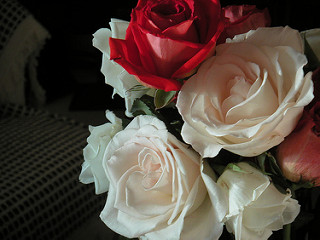

In [15]:
PIL.Image.open((roses[1]))

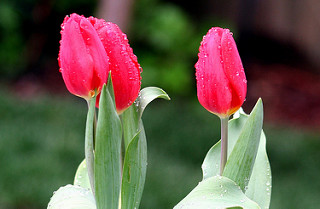

In [16]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

<h3 style='color:purple'>Read flowers images from disk into numpy array using opencv</h3>

In [17]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [18]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [19]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos_dataset/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [20]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos_dataset\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [21]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

cv2.imread(...) reads the image from disk and loads it into memory as a NumPy array.

In [22]:
img

array([[[ 0, 15,  6],
        [ 0, 15,  6],
        [ 0, 17,  8],
        ...,
        [24, 51, 31],
        [25, 52, 32],
        [26, 53, 33]],

       [[ 7, 22, 14],
        [ 7, 22, 14],
        [ 6, 21, 13],
        ...,
        [20, 46, 30],
        [23, 49, 33],
        [25, 51, 35]],

       [[12, 23, 15],
        [12, 23, 15],
        [11, 22, 14],
        ...,
        [20, 42, 30],
        [23, 45, 33],
        [26, 48, 36]],

       ...,

       [[19, 30, 27],
        [14, 24, 18],
        [12, 20, 13],
        ...,
        [ 4, 13,  3],
        [ 0,  8,  1],
        [ 0,  5,  0]],

       [[19, 30, 28],
        [18, 27, 24],
        [15, 23, 16],
        ...,
        [ 3, 12,  2],
        [ 1,  9,  2],
        [ 0,  7,  2]],

       [[ 9, 19, 19],
        [17, 25, 24],
        [22, 29, 24],
        ...,
        [ 1, 12,  2],
        [ 2, 10,  3],
        [ 3, 11,  4]]], shape=(240, 179, 3), dtype=uint8)

In [23]:
img.shape

(240, 179, 3)

In [24]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [25]:
X, y = [], []

In [26]:
for flower_name, images_path in flowers_images_dict.items():
    for image_path in images_path:
        img = cv2.imread(str(image_path))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [27]:
X

[array([[[ 1, 16,  7],
         [ 1, 16,  7],
         [ 1, 17,  9],
         ...,
         [23, 50, 31],
         [25, 51, 32],
         [26, 52, 33]],
 
        [[10, 23, 15],
         [10, 23, 15],
         [ 9, 22, 14],
         ...,
         [20, 44, 30],
         [23, 47, 33],
         [26, 50, 36]],
 
        [[13, 20, 13],
         [12, 20, 13],
         [11, 19, 12],
         ...,
         [21, 43, 30],
         [22, 45, 31],
         [25, 48, 34]],
 
        ...,
 
        [[12, 24, 18],
         [11, 22, 15],
         [12, 21, 11],
         ...,
         [ 7, 14,  7],
         [ 2,  8,  2],
         [ 0,  2,  0]],
 
        [[19, 30, 28],
         [16, 26, 21],
         [14, 22, 15],
         ...,
         [ 3, 12,  2],
         [ 0,  8,  1],
         [ 0,  6,  1]],
 
        [[11, 21, 20],
         [17, 25, 24],
         [21, 28, 23],
         ...,
         [ 1, 12,  2],
         [ 2, 10,  3],
         [ 3, 10,  4]]], shape=(180, 180, 3), dtype=uint8),
 array([[[13, 18, 17]

In [28]:
y

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [29]:
X = np.array(X)
y = np.array(y)

In [30]:
y

array([0, 0, 0, ..., 4, 4, 4], shape=(3670,))

<h3 style='color:purple'>Train test split</h3>

In [31]:
from sklearn.model_selection import train_test_split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

<h3 style='color:purple'>Preprocessing: scale images</h3>

In [33]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

<h3 style='color:purple'>Build convolutional neural network and train it</h3>

In [34]:
num_classes = 5

Number of classes,5 flower categories:

In [35]:
model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),#16 filters,3x3 kernel,ReLU activation
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


Each filter learns patterns such as:

Edges
Lines
Corners
Textures

Output:

180 x 180 x 16

because:

padding='same'

preserves image size.

Default:

pool_size=(2,2)

It reduces dimensions:

180 x 180 x 16
↓
90 x 90 x 16

and keeps the most important features.

Example:

4 7
2 3

becomes:

7

(max value)

Second Convolution Layer

90 x 90 x 16
↓
90 x 90 x 32

32 filters learn more complex patterns:

Petal shapes
Leaf structures
Flower textures

2nd pooling 
90 x 90 x 32
↓
45 x 45 x 32

Third Convolution
45 x 45 x 64
↓
22 x 22 x 64

CNN output:

22 x 22 x 64

Flatten converts it into:

22 × 22 × 64 = 30976

Output:

(30976,)

Creates:

128 neurons

This layer combines all extracted features.

It learns:

Petal shape + Color + Texture

to recognize flowers.

Output Layer ,num_classes = 5,that is it give 5 output,since here no activation funcn 

<img src="image1.png">

mathi dekhai anusar filter rakhda kheri , output ko shape nai change vaeko xa , 5*7 bata 3*5 ma 

<img src="image2.png">

normal filtering ma ke hunxa vane , mid ko pixel dherai wota convolution ma participate garxa, but corner pixel neglect hunxa

<img src="image3.png">

mathi ke hunxa vane ,corner pixel lai mid ma banauna lai , four wota side ma -1 wala row ra column add garinxa . ra eslai padding vaninxa , ra yo padding le garda input shape ra output shape same hunxa

padding=1 means shape same

In [36]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


Adam automatically adjusts learning rates.

Most commonly used optimizer for CNNs.

No softmax activation

The output might be:

[3.2, 1.5, -2.1, 0.8, 4.5]

These numbers are called logits

Network output:

[3.2, 1.5, -2.1, 0.8, 4.5]

Interpretation:

Daisy       : 3.2
Rose        : 1.5
Tulip       : -2.1
Sunflower   : 0.8
Dandelion   : 4.5

These are NOT probabilities.

Softmax transforms:

[3.2, 1.5, -2.1, 0.8, 4.5]

into:

[0.20, 0.04, 0.001, 0.02, 0.739]

0.20 + 0.04 + 0.001 + 0.02 + 0.739 = 1

from_logits=True means "Dear TensorFlow,
my model outputs raw logits,
please apply softmax internally
before calculating loss."

In [37]:
model.fit(X_train_scaled, y_train, epochs=10) 

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 158s 292ms/step - accuracy: 0.4397 - loss: 1.2956
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 200ms/step - accuracy: 0.5898 - loss: 1.0441
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.6708 - loss: 0.8656
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.7409 - loss: 0.6690
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 187ms/step - accuracy: 0.8241 - loss: 0.4730
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9012 - loss: 0.2966
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.9571 - loss: 0.1407
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.9804 - loss: 0.0705
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 237ms/step - accuracy: 0.9855 - loss: 0.0604
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.9851 - loss: 0.0621


In [38]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.6318 - loss: 1.7890


[1.7889655828475952, 0.6318082809448242]

**Here we see that while train accuracy is very high (99%), the test accuracy is significantly low (64%) indicating overfitting**

<h3 style='color:purple'>Improve Test Accuracy Using Data Augmentation</h3>

The augmentation layer can create:

Flipped image
Slightly rotated image
Slightly zoomed image

This increases the variety of training data without collecting new images.

In [39]:
data_augmentation =keras.Sequential([
    layers.RandomZoom(0.3,)
])

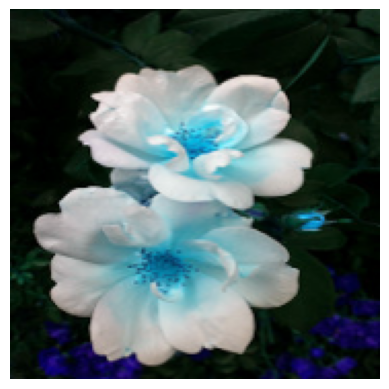

In [40]:
plt.axis('off')
plt.imshow(X[0])
plt.show()

In [41]:
data_augmentation(X)[0].numpy().astype("uint8")

array([[[  0,   3,   0],
        [  0,   3,   0],
        [  0,   2,   0],
        ...,
        [  3,  12,   9],
        [  0,   9,   3],
        [  2,  12,   1]],

       [[  1,   5,   0],
        [  0,   3,   0],
        [  0,   2,   0],
        ...,
        [  5,  21,  14],
        [  1,  15,   6],
        [  1,  12,   1]],

       [[  0,   5,   0],
        [  0,   4,   0],
        [  0,   3,   0],
        ...,
        [  5,  24,  13],
        [  3,  18,   7],
        [  3,  13,   3]],

       ...,

       [[  9,   2,  51],
        [ 10,   4,  40],
        [  7,   6,  22],
        ...,
        [ 13,   5,  59],
        [ 17,  10,  63],
        [ 20,  22,  62]],

       [[ 31,  13,  99],
        [ 33,  15,  93],
        [ 20,  12,  58],
        ...,
        [ 17,   5,  63],
        [ 29,  12,  78],
        [ 21,  11,  61]],

       [[ 37,  19, 111],
        [ 31,  14,  99],
        [ 17,   7,  68],
        ...,
        [ 25,  12,  60],
        [ 25,  12,  56],
        [ 14,   6,  49]]

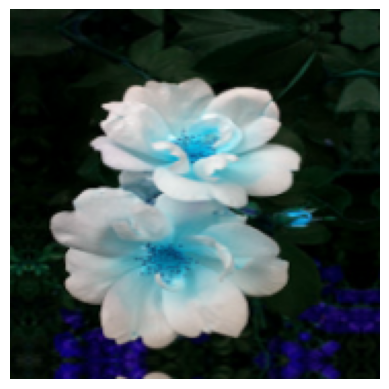

In [42]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [43]:
img_height = 180
img_width = 180

In [44]:
data_augmentation = keras.Sequential([
    layers.RandomFlip(
        "horizontal",
        input_shape=(img_height, img_width, 3)
    ),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

c:\Users\Admin HP\OneDrive\Desktop\MyDataScienceProject\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<h3 style='color:purple'>Train the model using data augmentation and a drop out layer</h3>

In [45]:
num_classes = 5

In [46]:
model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


In [47]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [48]:
model.fit(X_train_scaled, y_train, epochs=10) 

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 210s 632ms/step - accuracy: 0.4568 - loss: 1.2659
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4644s 25s/step - accuracy: 0.5977 - loss: 1.0059
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 269ms/step - accuracy: 0.6381 - loss: 0.9116
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 362ms/step - accuracy: 0.6650 - loss: 0.8548
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 338ms/step - accuracy: 0.6860 - loss: 0.8036
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 280ms/step - accuracy: 0.7020 - loss: 0.7500
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 330ms/step - accuracy: 0.7329 - loss: 0.7074
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.7424 - loss: 0.6711
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 328ms/step - accuracy: 0.7485 - loss: 0.6670
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.7682 - loss: 0.6276


In [49]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 47s 615ms/step - accuracy: 0.7037 - loss: 0.7206


[0.7206339836120605, 0.7037037014961243]

**You can see that by using data augmentation and drop out layer the accuracy of test set predictions is increased to 70.37%